In [1]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.lines import Line2D

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

fig_width = 11.27

# Figure Results 4

## Example spikes in each synapse

In [2]:
def read_spike_times(idx, rate, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"
    
    spike_times = pd.read_csv(
        f"output/temporal-interference-1/{idx}/random_poisson/{rate}/{filename}/synapse_stimuli.csv",
        header = None
    )
    spike_times = spike_times.fillna('').values.tolist()
    spike_times = [[x for x in row if x != ""] for row in spike_times]
    
    return spike_times

In [3]:
idx = 0
rate = 5
initial_weight = 0.1

spike_times = read_spike_times(
    idx = idx,
    rate = rate,
    initial_weight = initial_weight,
    carrier = None
)

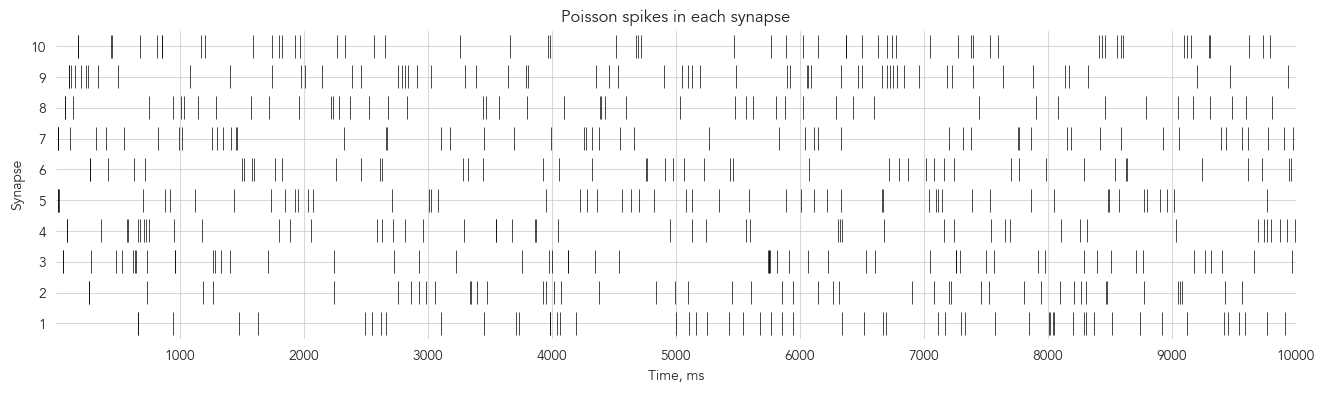

In [4]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (16, 4))
ax = axs

for i, spikes in enumerate(spike_times):
    ax.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax.set_ylim(0.5, 10.5)
ax.set_ylabel("Synapse")
ax.set_yticks(np.arange(1, 11, 1))

ax.set_xlabel("Time, ms")
ax.set_xticks(np.arange(1000, 10_000 + 1000, 1000))
ax.set_xlim(0, 10_000)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Poisson spikes in each synapse")
ax.grid(alpha = 0.75)
plt.show()

**Figure**. Spike times in each synapse. Generated independently for each synapse and each synaptic configuration.

## Distribution of Poisson spike ISI

In [5]:
def isi_from_times(spike_times):
    return np.concatenate([ np.diff(spikes) for spikes in spike_times ])

In [6]:
def read_all_isi_rate(rate, carrier = 1000):
    idxs = np.arange(0, 20)
    
    isi = []
    
    for idx in idxs:
        spike_times = read_spike_times(idx = idx, rate = rate, initial_weight = initial_weight, carrier = None)
        isi.append(isi_from_times(spike_times))
    
        spike_times = read_spike_times(idx = idx, rate = rate, initial_weight = initial_weight, carrier = carrier, offset = 5, strength = 0.9)
        isi.append(isi_from_times(spike_times))
    
        spike_times = read_spike_times(idx = idx, rate = rate, initial_weight = initial_weight, carrier = carrier, offset = 130, strength = 0.9)
        isi.append(isi_from_times(spike_times))
    
        spike_times = read_spike_times(idx = idx, rate = rate, initial_weight = initial_weight, carrier = carrier, offset = 0, strength = 0.32)
        isi.append(isi_from_times(spike_times))
    
    isi = np.concatenate(isi)
    
    return isi

In [7]:
isi_5 = read_all_isi_rate(rate = 5)
isi_10 = read_all_isi_rate(rate = 10)
isi_30 = read_all_isi_rate(rate = 30)

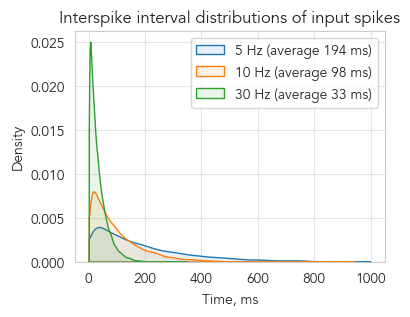

In [8]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 3))
ax = axs

sns.kdeplot(
    isi_5,
    bw_adjust = 1,
    ax = ax,
    clip = (0, 1000),
    label = f"5 Hz (average {round(np.mean(isi_5))} ms)",
    fill = True,
    alpha = 0.1
)

sns.kdeplot(
    isi_10,
    bw_adjust = 1,
    ax = ax,
    clip = (0, 1000),
    label = f"10 Hz (average {round(np.mean(isi_10))} ms)",
    fill = True,
    alpha = 0.1
)

sns.kdeplot(
    isi_30,
    bw_adjust = 1,
    ax = ax,
    clip = (0, 1000),
    label = f"30 Hz (average {round(np.mean(isi_30))} ms)",
    fill = True,
    alpha = 0.1
)

ax.set_xlabel("Time, ms")
ax.set_title("Interspike interval distributions of input spikes")
ax.legend()
ax.grid(alpha = 0.5)
plt.show()

## Average synaptic weights

In [9]:
idxs = np.arange(0, 20)

In [10]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

In [11]:
def read_weights(rate, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    project = "temporal-interference-1"

    synapses = [f"Synapse{i}" for i in range(10)]
    weights = []
    time = []
    for idx in idxs:
        weights_idx = pd.read_csv(f"output/{project}/{idx}/random_poisson/{rate}/{filename}/synapse_weights.csv", index_col = 0)
        weights_idx = expand_time(weights_idx)

        for synapse in synapses:
            weights.append(weights_idx[synapse])

        time = weights_idx.Time

    weights = np.vstack(weights)

    return time, weights

In [12]:
def pad_edges(data, pad_width):
    return np.pad(data, pad_width, mode="edge")

In [13]:
def smooth_data(data, window_size=10):
    dt = np.convolve(data, np.ones(window_size)/window_size, mode="valid")
    len_diff = len(data) - len(dt)

    return pad_edges(dt, int(len_diff / 2))

In [14]:
def get_colours():
    return {
        "No TI": "tab:blue",
        "5 Hz TI": "tab:orange",
        "130 Hz TI": "tab:green",
        "0 Hz TI": "tab:red"
    }

In [15]:
def plot_average_synweight(
        ax,
        rate = 5,
        carrier = 1000,
        initial_weight = 0.1,
        remove_left_labels = False
):
    time_no_ti, weights_no_ti = read_weights(rate = rate, carrier = None, initial_weight = initial_weight)
    time_5, weights_5 = read_weights(rate = rate, carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
    time_130, weights_130 = read_weights(rate = rate, carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
    time_0, weights_0 = read_weights(rate = rate, carrier = carrier, offset = 0, strength = 0.32, initial_weight = initial_weight)

    colors = get_colours()

    for weights, time, condition in zip(
            [weights_no_ti, weights_5, weights_130, weights_0],
            [time_no_ti, time_5, time_130, time_0],
            ["No TI", "5 Hz TI", "130 Hz TI", "0 Hz TI"]
    ):
        mean = smooth_data(weights.mean(axis = 0), window_size = 1000)
        error = weights.std(axis = 0) / np.sqrt(weights.shape[0])
        error = error[:-1]
        time = time[:-1] / 1000
    
        color = colors[condition]
    
        ax.plot(
            time,
            mean,
            linewidth = 1,
            label = condition,
            color = color
        )
        ax.fill_between(
            time, mean - error, mean + error,
            alpha = 0.25,
            color = color,
            edgecolor = None
        )
    
    if remove_left_labels:
        ax.tick_params(left = False, labelleft = False)
    
    if not remove_left_labels:
        ax.set_ylabel("Synaptic weight")
    
    ax.set_xlabel("Time, s")
    ax.set_ylim(-0.05, 0.6)
    ax.set_xticks(np.arange(0, 10 + 2, 2))
    ax.set_yticks(np.arange(0, 0.6, 0.1))

    sns.despine(ax = ax, top = True, right = True)
    
    ax.grid(True, alpha = 0.25)

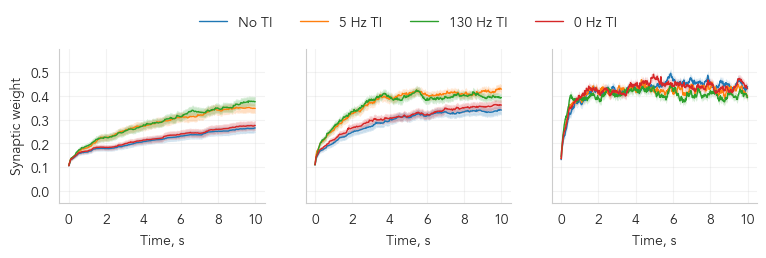

In [16]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (9, 2))

plot_average_synweight(
    ax = axs[0],
    rate = 5
)

plot_average_synweight(
    ax = axs[1],
    rate = 10,
    remove_left_labels = True
)

plot_average_synweight(
    ax = axs[2],
    rate = 30,
    remove_left_labels = True
)

axs[1].legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.3))
plt.show()

## Distribution of final weights

In [17]:
def plot_dist_weights(
        ax,
        rate = 5,
        carrier = 1000,
        initial_weight = 0.1,
        remove_left_labels = False
):
    time_no_ti, weights_no_ti = read_weights(rate = rate, carrier = None, initial_weight = initial_weight)
    time_5, weights_5 = read_weights(rate = rate, carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
    time_130, weights_130 = read_weights(rate = rate, carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
    time_0, weights_0 = read_weights(rate = rate, carrier = carrier, offset = 0, strength = 0.32, initial_weight = initial_weight)
    
    colors = get_colours()

    sns.kdeplot(
        weights_no_ti[:, -1],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = "No TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["No TI"]
    )

    sns.kdeplot(
        weights_5[:, -1],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = "5 Hz TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["5 Hz TI"]
    )
    
    sns.kdeplot(
        weights_130[:, -1],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = "130 Hz TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["130 Hz TI"]
    )
    
    sns.kdeplot(
        weights_0[:, -1],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = "0 Hz TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["0 Hz TI"]
    )
    
    ax.grid(True, alpha = 0.25)
    ax.set_xticks(np.arange(0, 1 + 0.25, 0.25))
    
    ax.set_ylim(0, 3)
    ax.set_yticks(np.arange(0, 3, 1))

    if remove_left_labels:
        ax.tick_params(left = False, labelleft = False)
        ax.set_ylabel("")
    
    ax.set_xlabel("Synaptic weight")

    sns.despine(ax = ax, top = True, right = True)

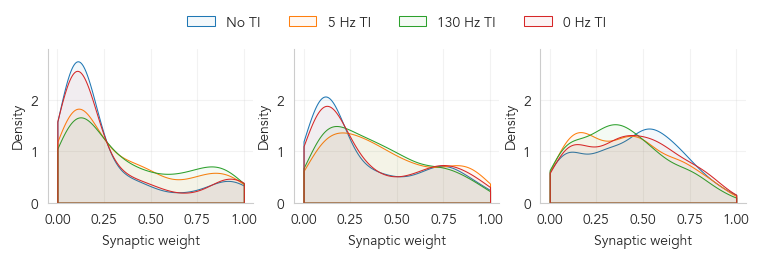

In [18]:
_, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (9, 2))

plot_dist_weights(
    ax = axs[0],
    rate = 5
)

plot_dist_weights(
    ax = axs[1],
    rate = 10
)

plot_dist_weights(
    ax = axs[2],
    rate = 30
)

axs[1].legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.3))

plt.show()

# Firing frequency

In [19]:
def read_firing_frequency(rate, carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    project = "temporal-interference-1"

    freqs = []
    for idx in idxs:
        freq = pd.read_csv(f"output/{project}/{idx}/random_poisson/{rate}/{filename}/spike_frequency.csv", index_col = 0)
        
        if len(freq) > 0:
            freqs.append(freq)

    freqs = pd.concat(freqs, ignore_index = True)

    return freqs

In [20]:
def plot_dist_freq(
        ax,
        rate = 5,
        carrier = 1000,
        initial_weight = 0.1,
        remove_left_labels = False
):
    freq_no_ti = read_firing_frequency(rate = rate, carrier = None, initial_weight = initial_weight)
    freq_5 = read_firing_frequency(rate = rate, carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
    freq_130 = read_firing_frequency(rate = rate, carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
    freq_0 = read_firing_frequency(rate = rate, carrier = carrier, offset = 0, strength = 0.32, initial_weight = initial_weight)

    colors = get_colours()

    sns.kdeplot(
        freq_no_ti.Frequency,
        bw_adjust = 1,
        ax = ax,
        clip = (0, 50),
        label = "No TI",
        fill = True,
        alpha = 0.1,
        color = colors["No TI"]
    )

    sns.kdeplot(
        freq_5.Frequency,
        bw_adjust = 1,
        ax = ax,
        clip = (0, 50),
        label = "5 Hz TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["5 Hz TI"]
    )
    
    sns.kdeplot(
        freq_130.Frequency,
        bw_adjust = 1,
        ax = ax,
        clip = (0, 50),
        label = "130 Hz TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["130 Hz TI"]
    )
    
    sns.kdeplot(
        freq_0.Frequency,
        bw_adjust = 1,
        ax = ax,
        clip = (0, 50),
        label = "0 Hz TI",
        fill = True,
        alpha = 0.05,
        linewidth = 0.75,
        color = colors["0 Hz TI"]
    )
    
    ax.grid(True, alpha = 0.25)
    ax.set_xticks(np.arange(0, 50 + 10, 10))
    
    ax.set_xlabel("Frequency")

    if remove_left_labels:
        ax.tick_params(left = False, labelleft = False)
        ax.set_ylabel("")
    
    sns.despine(ax = ax, top = True, right = True)

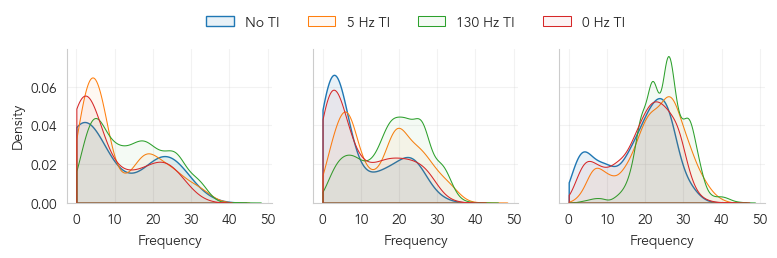

In [21]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (9, 2), sharey = True, sharex = True)

plot_dist_freq(
    ax = axs[0],
    rate = 5
)

plot_dist_freq(
    ax = axs[1],
    rate = 10
)

plot_dist_freq(
    ax = axs[2],
    rate = 30
)

axs[1].legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.3))

plt.show()

# Full figure

In [22]:
isi_5 = read_all_isi_rate(rate = 5) / 1000
isi_10 = read_all_isi_rate(rate = 10) / 1000
isi_30 = read_all_isi_rate(rate = 30) / 1000

In [23]:
def read_somatic_voltage(
        idx,
        rate = 5,
        initial_weight = 0.1,
        carrier = 1000,
        strength = 0.9,
        offset = 5
):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"

    voltage = pd.read_csv(
        f"output/temporal-interference-1/{idx}/random_poisson/{rate}/{filename}/voltage.csv",
        index_col = 0
    )

    return voltage

In [24]:
idx = 0

voltage_no_ti = read_somatic_voltage(idx = idx, carrier = None)
voltage_5 = read_somatic_voltage(idx = idx, offset = 5)
voltage_130 = read_somatic_voltage(idx = idx, offset = 130)
voltage_0 = read_somatic_voltage(idx = idx, offset = 0, strength = 0.32)

In [25]:
def plot_voltage(ax, voltage, condition, remove_x = False):
    colors = get_colours()
    color = colors[condition]
    
    ax.plot(
        voltage.Time / 1000,
        voltage.Voltage,
        linewidth = 0.5,
        color = color
    )

    ax.set_ylim(-90, 70)
    ax.set_xlim(0, 10)
    
    ax.grid(True, alpha = 0.25)

    ax.set_yticks(np.arange(-50, 50 + 10, 50))
    ax.tick_params(left = True, labelleft = True)

    sns.despine(ax = ax, top = True, right = True)
    
    ax.set_ylabel("Voltage, mV", fontsize = 9)
    ax.set_xlabel("Time, s")
    
    if remove_x:
        ax.set_xlabel("")
        ax.tick_params(bottom = False, labelbottom = False)
        sns.despine(ax = ax, top = True, right = True, bottom = True)

In [26]:
mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

Panel A
Panel B
Panel C
Panel D
Panel E
Panel F


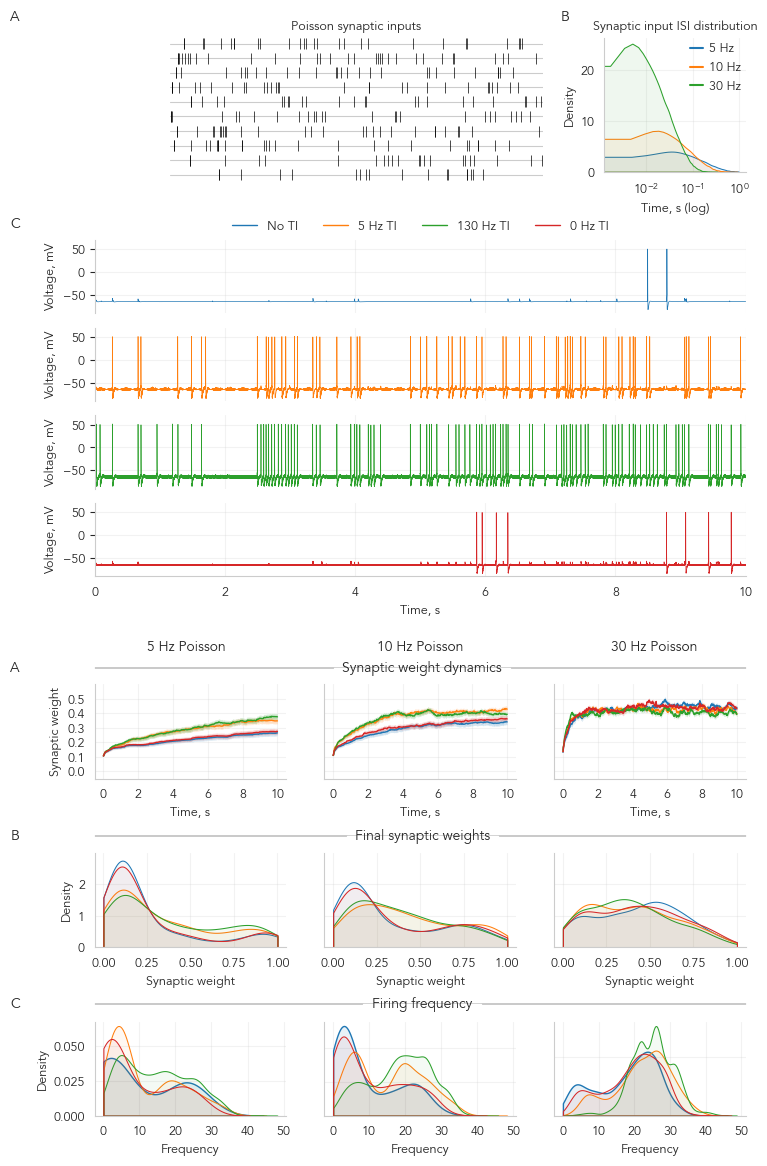

In [27]:
fig = plt.figure(figsize = (8.4, 14))

outer_gs = gridspec.GridSpec(9, 1, height_ratios = [1, 0.2, 2.5, 0.5, 0.7, 0.25, 0.7, 0.25, 0.7])

# --- A and B panels ---

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec = outer_gs[0], width_ratios = [0.1, 0.79, 0.01, 0.3])

### A

print("Panel A")

ax_a = fig.add_subplot(inner_gs[1])

for i, spikes in enumerate(spike_times):
    ax_a.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax_a.set_yticks(np.arange(1, 11, 1))
ax_a.set_yticklabels([])

ax_a.set_xlabel("")
ax_a.set_xlim(0, 5000)
ax_a.tick_params(axis = "x", labelbottom = False, which = "both", bottom = False)

ax_a.grid(True)
ax_a.xaxis.grid(False)
ax_a.yaxis.grid(True)

sns.despine(ax = ax_a, top = True, bottom = True, left = True, right = True)

ax_a.set_title("Poisson synaptic inputs", y = 0.925)

## B

print("Panel B")

ax_b = fig.add_subplot(inner_gs[3])

sns.kdeplot(
    isi_5,
    bw_adjust = 1,
    ax = ax_b,
    clip = (0, 1),
    label = "5 Hz",
    fill = True,
    alpha = 0.075,
    linewidth = 0.75
)

sns.kdeplot(
    isi_10,
    bw_adjust = 1,
    ax = ax_b,
    clip = (0, 1),
    label = "10 Hz",
    fill = True,
    alpha = 0.075,
    linewidth = 0.75
)

sns.kdeplot(
    isi_30,
    bw_adjust = 1,
    ax = ax_b,
    clip = (0, 1),
    label = "30 Hz",
    fill = True,
    alpha = 0.075,
    linewidth = 0.75
)

ax_b.set_xlabel("Time, s (log)")
ax_b.set_title("Synaptic input ISI distribution")
ax_b.grid(alpha = 0.25)

handles, labels = ax_b.get_legend_handles_labels()
line_handles = [
    Line2D([], [], color = h.get_edgecolor(), label = label)
    for h, label in zip(handles, labels)
]

ax_b.legend(
    handles = line_handles,
    loc = "upper right",
    frameon = False,
    ncol = 1,
    handletextpad = 0.5,
    handlelength = 1.0,
    bbox_to_anchor = (1, 1),
    borderaxespad = 0
)

ax_b.set_xscale("log")

sns.despine(ax = ax_b, top = True, right = True)

#### Adjust position of A
pos_b = ax_b.get_position()
pos_a = ax_a.get_position()

ax_a.set_position([pos_a.x0, pos_b.y0 - 0.015, pos_a.width, pos_b.height * 1.25])

# --- C panel ---
# Example voltage traces showing spiking dynamics during various stimulation protocols

print("Panel C")

inner_gs = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec = outer_gs[2])

axs = [fig.add_subplot(inner_gs[i, 0]) for i in range(4)]

plot_voltage(axs[0], voltage_no_ti, condition = "No TI", remove_x = True)
plot_voltage(axs[1], voltage_5, condition = "5 Hz TI", remove_x = True)
plot_voltage(axs[2], voltage_130, condition = "130 Hz TI", remove_x = True)
plot_voltage(axs[3], voltage_0, condition = "0 Hz TI", remove_x = False)

#### Annotations of inputs

left = 0.125
right = 0.9
third_width = (right - left) / 3

fig.text(x = ((left + third_width * 0) + (left + third_width * 1)) / 2 - 0.02, y = 0.45, s = "5 Hz Poisson", ha = "center", va = "top", fontsize = 10)
fig.text(x = ((left + third_width * 1) + (left + third_width * 2)) / 2, y = 0.45, s = "10 Hz Poisson", ha = "center", va = "top", fontsize = 10)
fig.text(x = ((left + third_width * 2) + (left + third_width * 3)) / 2 + 0.02, y = 0.45, s = "30 Hz Poisson", ha = "center", va = "top", fontsize = 10)

# --- D panel ---
# Synaptic weight dynamics with random poisson inputs at different frequencies

print("Panel D")

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[4])

axs = [fig.add_subplot(inner_gs[0, i]) for i in range(3)]

plot_average_synweight(
    ax = axs[0],
    rate = 5
)

plot_average_synweight(
    ax = axs[1],
    rate = 10,
    remove_left_labels = True
)

plot_average_synweight(
    ax = axs[2],
    rate = 30,
    remove_left_labels = True
)

# Adding legend (above c)
axs[1].legend(
    loc = "upper center",
    ncol = 4,
    frameon = False,
    bbox_to_anchor = (0.5, 6.05)
)

line = Line2D([0.125, 0.9], [0.43, 0.43], transform = fig.transFigure, color = "black", linestyle = "-", linewidth = 0.3)
fig.add_artist(line)

line = Line2D([0.41, 0.62], [0.43, 0.43], transform = fig.transFigure, color = "white", linestyle = "-", linewidth = 1)
fig.add_artist(line)

fig.text(x = 0.515, y = 0.435, s = "Synaptic weight dynamics", ha = "center", va = "top", fontsize = 10)

# --- E panel ---
# Distribution of final synaptic weight

print("Panel E")

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[6])
axs = [fig.add_subplot(inner_gs[0, i]) for i in range(3)]

plot_dist_weights(
    ax = axs[0],
    rate = 5
)

plot_dist_weights(
    ax = axs[1],
    rate = 10,
    remove_left_labels = True,
)

plot_dist_weights(
    ax = axs[2],
    rate = 30,
    remove_left_labels = True
)

line = Line2D([0.125, 0.9], [0.31, 0.31], transform = fig.transFigure, color = "black", linestyle = "-", linewidth = 0.3)
fig.add_artist(line)

line = Line2D([0.425, 0.605], [0.31, 0.31], transform = fig.transFigure, color = "white", linestyle = "-", linewidth = 1)
fig.add_artist(line)

fig.text(x = 0.515, y = 0.315, s = "Final synaptic weights", ha = "center", va = "top", fontsize = 10)

# --- F panel ---
# Distribution of firing frequency

print("Panel F")

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = outer_gs[8])
axs = [fig.add_subplot(inner_gs[0, i]) for i in range(3)]

plot_dist_freq(
    ax = axs[0],
    rate = 5
)

plot_dist_freq(
    ax = axs[1],
    rate = 10,
    remove_left_labels = True
)

plot_dist_freq(
    ax = axs[2],
    rate = 30,
    remove_left_labels = True
)

line = Line2D([0.125, 0.9], [0.19, 0.19], transform = fig.transFigure, color = "black", linestyle = "-", linewidth = 0.3)
fig.add_artist(line)

line = Line2D([0.445, 0.585], [0.19, 0.19], transform = fig.transFigure, color = "white", linestyle = "-", linewidth = 1)
fig.add_artist(line)

fig.text(x = 0.515, y = 0.195, s = "Firing frequency", ha = "center", va = "top", fontsize = 10)

### Labels

fig.text(x = 0.03, y = 0.9, s = "A", ha = "center", va = "top", fontsize = 10)
fig.text(x = 0.685, y = 0.9, s = "B", ha = "center", va = "top", fontsize = 10)
fig.text(x = 0.03, y = 0.752, s = "C", ha = "center", va = "top", fontsize = 10)
fig.text(x = 0.03, y = 0.435, s = "A", ha = "center", va = "top", fontsize = 10)
fig.text(x = 0.03, y = 0.315, s = "B", ha = "center", va = "top", fontsize = 10)
fig.text(x = 0.03, y = 0.195, s = "C", ha = "center", va = "top", fontsize = 10)

plt.savefig("figure_after.png", dpi = 500, bbox_inches = "tight")
plt.show()

In [30]:
project = "temporal-interference-1"
spike_times = pd.read_csv(f"output/{project}/in_vivo_stimuli.csv", index_col = 0).to_numpy().T

Panel A


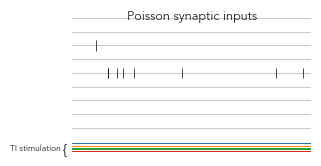

In [31]:
fig = plt.figure(figsize = (8.4, 14))

outer_gs = gridspec.GridSpec(9, 1, height_ratios = [1, 0.2, 2.5, 0.5, 0.7, 0.25, 0.7, 0.25, 0.7])

# --- A and B panels ---

inner_gs_1 = gridspec.GridSpecFromSubplotSpec(5, 4, subplot_spec = outer_gs[0], width_ratios = [0.1, 0.3, 0.01, 0.3], height_ratios = [0.9, 0.01, 0.01, 0.01, 0.01], hspace = 0.05)

### A

print("Panel A")

ax_a = fig.add_subplot(inner_gs_1[0, 1])

for i, spikes in enumerate(spike_times):
    ax_a.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

ax_a.set_yticks(np.arange(1, 11, 1))
ax_a.set_yticklabels([])

ax_a.set_xlabel("")
ax_a.set_xlim(0, 3000)
ax_a.tick_params(axis = "x", labelbottom = False, which = "both", bottom = False)

ax_a.grid(True)
ax_a.xaxis.grid(False)
ax_a.yaxis.grid(True)

sns.despine(ax = ax_a, top = True, bottom = True, left = True, right = True)

ax_a.set_title("Poisson synaptic inputs", y = 0.925)

################## The BLUE line

ax = fig.add_subplot(inner_gs_1[1, 1])

ax.axvspan(
    0,
    3000,
    color = "tab:blue",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

################## The ORANGE line

ax = fig.add_subplot(inner_gs_1[2, 1])

ax.axvspan(
    0,
    3000,
    color = "tab:orange",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# The GREEN line

ax = fig.add_subplot(inner_gs_1[3, 1])

ax.axvspan(
    0,
    3000,
    color = "tab:green",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks(np.arange(0, 3200, 500))
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False, labelbottom = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# The RED line

ax = fig.add_subplot(inner_gs_1[4, 1])

ax.axvspan(
    0,
    3000,
    color = "tab:red",
    zorder = 1,
    linewidth = 0
)

ax.set_xlim(0, 3000)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylim(-0.5, 0.5)
ax.tick_params(left = False, labelleft = False)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(0.21, 0.78665, "TI stimulation", fontsize = 6, va = "center", ha = "center")
fig.text(0.245, 0.78665, "{", fontsize = 10, va = "center", ha = "center")

plt.savefig("figure4_protocol.png", dpi = 500, bbox_inches = "tight", transparent=True)
plt.show()